Dataset Shape: (4600, 18)
                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renova

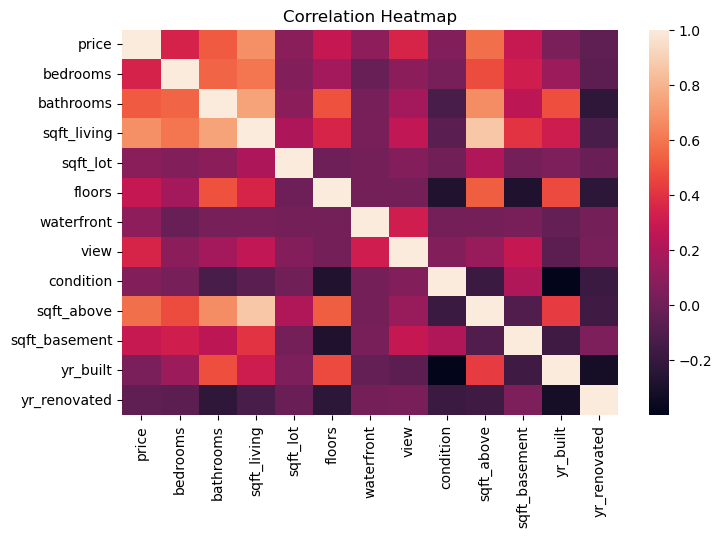


Model Comparison:
                                  MAE           RMSE        R2
Linear Regression      140943.715164  192080.326906  0.526407
Ridge Regression       139965.549897  191790.728120  0.527834
Lasso Regression       139982.009577  191805.661490  0.527760
Polynomial Regression  143873.763093  210373.729844  0.431903

Best Model: Ridge Regression
Model saved successfully ✔

Sample Predictions:
[366557.40741572 487669.99794148 494506.00164357 433772.69409182
 285117.61493304]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.037e+11, tolerance: 3.108e+10
  model = cd_fast.enet_coordinate_descent(


In [3]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ===============================
# 2. LOAD DATA
# ===============================
df = pd.read_csv("data.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ===============================
# 3. DATA CLEANING
# ===============================
df.drop(["date","street","city","statezip","country"], axis=1, inplace=True)

df.fillna(df.median(numeric_only=True), inplace=True)

# ===============================
# 4. OUTLIER HANDLING
# ===============================
q_low = df["price"].quantile(0.01)
q_high = df["price"].quantile(0.99)

df = df[(df["price"] > q_low) & (df["price"] < q_high)]

print("After outliers:", df.shape)

# ===============================
# 5. QUICK EDA (OPTIONAL SAFE)
# ===============================
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()

# ===============================
# 6. FEATURES & TARGET
# ===============================
X = df.drop("price", axis=1)
y = df["price"]

# ===============================
# 7. TRAIN TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 8. MODELS
# ===============================
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10))
    ]),

    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=1.0, max_iter=10000))
    ]),

    "Polynomial Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", LinearRegression())
    ])
}

# ===============================
# 9. TRAIN + EVALUATION
# ===============================
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results[name] = {
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    }

results_df = pd.DataFrame(results).T
print("\nModel Comparison:\n", results_df)

# ===============================
# 10. BEST MODEL SELECTION
# ===============================
best_model_name = results_df["R2"].idxmax()
print("\nBest Model:", best_model_name)

best_model = models[best_model_name]

# ===============================
# 11. SAVE MODEL (IMPORTANT FIX)
# ===============================
pickle.dump(best_model, open("best_model.pkl", "wb"))

print("Model saved successfully ✔")

# ===============================
# 12. TEST PREDICTION
# ===============================
loaded_model = pickle.load(open("best_model.pkl", "rb"))

sample = X.iloc[:5]
print("\nSample Predictions:")
print(loaded_model.predict(sample))